# XGBoost Hyperparameter Tuning

Two-phase tuning using anchored-expanding cross-validation. The data and approach is as follows

0. **Data and split**
    - Top 5,000 Tickers by liquidity as of March 12th 2026 (_Narrowed to ~3,500 to remove ETFs_)
    - 3 folds for training with: >= 20 years of training data, 8 years of validation, and 8 years of holdout. Includes a 1 month embargo period between sets
1. **Phase 1 (Random search)**
    - Broad random search across ~25 potential configs to understand the hyperparameter landscape and narrow ranges
2. **Phase 2 (Bayesian search)**
    - Optuna Bayesian optimization over the narrowed search space

# Modeling Data Prep
- Calculate next-month returns on daily OHLCV data
- Merge on fundamentals updated at each quarter using SEC data from EDGAR API
- Calculate cross-sectional variables separately for each data split on each CV fold: this ensures that information is not leaked across train/val/holdout

# Findings
- Using GKX variables (fundamentals + standard price variables) and ranking next month returns is effective without a robust variables selection
- Training on standard-scaled next month returns out-performs training on raw returns when evaluating on raw returns

# Next steps
- Apply a robust variable selection and evaluation process for XGBoost model
- Once above is done:
    - Build additional models: Regularized GLM, ResNet, Ensemble framework
    - Determine how to best-incorporate news data (_rolling embeddings? Monthly aggregated embeddings, etc._)
    - Consider additional data sources?
- Consider how models on raw returns and residualized returns can be used together
    - Inputs to a meta learner predicting raw returns? 
    - Then, portfolio construction could be based on a regime model 

In [2]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from scipy.stats import spearmanr
import time
import optuna
from joblib import Parallel, delayed
import multiprocessing
import xgboost as xgb


from src.features.gkx_registry import GKX_94
from src.ensemble import anchored_expanding_cv, XGBRanker
from src.modeling.add_cross_sectional_features import (
    add_all_cross_sectional_features
)

c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [241]:
ff_3factors_path = "../data/downloaded/F-F_Research_Data_Factors.csv"
ff_mom_path = "../data/downloaded/F-F_Momentum_Factor.csv"

# --- Load and clean Fama-French factors
ff = pd.read_csv(ff_3factors_path, skiprows=3)

# Fix column names and only keep year-month values
ff.columns = ["year_month"] + list(ff.columns[1:])

# keep only rows with YYYYMM structure
ff["year_month"] = pd.to_numeric(ff["year_month"], errors="coerce")
ff = ff.dropna(subset=["year_month"])

# create YYYYMMDD integer for first day of month
ff["ymd_int"] = (ff["year_month"].astype(int).astype(str) + "01").astype(int)
ff = ff.query("ymd_int > 999999") 

# convert to datetime
ff["month_start"] = pd.to_datetime(ff["ymd_int"], format="%Y%m%d")
ff["month_end"] = ff["month_start"] + pd.offsets.MonthEnd(0)

# ensure numeric factors
ff["RF"] = pd.to_numeric(ff["RF"], errors="coerce")





# # --- Load and clean momentum data
# mom = pd.read_csv(ff_mom_path, skiprows=13)

# # Fix column names and only keep year-month values
# mom.head()
# new_mom_columns = ["year_month"] + list(mom.columns[1:])
# mom.columns = new_mom_columns

# mom["year_month"] = pd.to_numeric(mom["year_month"], errors="coerce")
# mom = mom.query("year_month > 9999") 

In [ ]:
ff[["month_end", "RF"]]

,year_month,Mkt-RF,SMB,HML,RF,ymd_int,month_start,month_end
0,192607.0,2.89,-2.55,-2.39,0.22,19260701,1926-07-01,1926-07-31
1,192608.0,2.64,-1.14,3.81,0.25,19260801,1926-08-01,1926-08-31
2,192609.0,0.38,-1.36,0.05,0.23,19260901,1926-09-01,1926-09-30
3,192610.0,-3.27,-0.14,0.82,0.32,19261001,1926-10-01,1926-10-31
4,192611.0,2.54,-0.11,-0.61,0.31,19261101,1926-11-01,1926-11-30
...,...,...,...,...,...,...,...,...
1190,202509.0,3.39,-1.85,-1.05,0.33,20250901,2025-09-01,2025-09-30
1191,202510.0,1.96,-0.55,-3.10,0.37,20251001,2025-10-01,2025-10-31
1192,202511.0,-0.13,0.38,3.76,0.30,20251101,2025-11-01,2025-11-30
1193,202512.0,-0.36,-1.06,2.42,0.34,20251201,2025-12-01,2025-12-31


In [ ]:
# For risk free rate-adjusted returns, use RF rate from beginning of month for end of month 
# to avoid future leakage

KeyError: ''

In [200]:
daily.head()

,ticker,date,open,high,low,close,volume,momentum_5,volatility_5,sma_5,...,UNRATE,PAYEMS,ICSA,UMCSENT,RSXFS,VIXCLS,DCOILWTICO,M2SL,TOTALSL,month_end
0,A,1999-11-18,32.546494,35.765381,28.612303,31.473534,62546380.0,NaN,NaN,NaN,...,4.1,130466.0,281000.0,107.2,234425.0,19.76,25.71,4611.8,1525334.42,1999-11-30
1,A,1999-11-19,30.713518,30.758226,28.478184,28.880545,15234146.0,NaN,NaN,NaN,...,4.1,130466.0,281000.0,107.2,234425.0,19.11,26.61,4611.8,1525334.42,1999-11-30
2,A,1999-11-22,29.551144,31.473534,28.657009,31.473534,6577870.0,NaN,NaN,NaN,...,4.1,130466.0,276000.0,107.2,234425.0,19.98,28.03,4611.8,1525334.42,1999-11-30
3,A,1999-11-23,30.400572,31.205294,28.612303,28.612303,5975611.0,NaN,NaN,NaN,...,4.1,130466.0,276000.0,107.2,234425.0,21.00,26.91,4611.8,1525334.42,1999-11-30
4,A,1999-11-24,28.701717,29.998213,28.612303,29.372318,4843231.0,NaN,NaN,29.962447,...,4.1,130466.0,276000.0,107.2,234425.0,20.26,27.22,4611.8,1525334.42,1999-11-30


In [186]:
# # TODO - Create beta neutral residualized returns
# import statsmodels.api as sm

# def residualize_returns(df):
#     """Create residual returns that cannot be explained by market momentum"""

#     df = df.copy()

#     residuals = []

#     for date, g in df.groupby("month_end"):

#         g = g.dropna(subset=["ret_eom_t+1", "Mkt-RF", "MOM"])

#         if len(g) < 20:
#             continue

#         y = g["ret_eom_t+1"]

#         X = g[["Mkt-RF", "MOM"]]
#         X = sm.add_constant(X)

#         model = sm.OLS(y, X).fit()

#         g["res_ret_eom_t+1"] = model.resid

#         residuals.append(g)

#     return pd.concat(residuals)

# df_res = residualize_returns(df)

In [ ]:
# -- Load data (monthly modeling panel) --
run_tag = "run_5000_nonetf_1980"
gkx_path = f"../data/processed/{run_tag}/gkx_monthly.parquet"
daily_path = f"../data/processed/{run_tag}/final_dataset.parquet"
etf_flag_path = "../data/universe/top_5000_equities_by_liquidity.csv"
ff_3factors_path = "../data/downloaded/F-F_Research_Data_Factors.csv"
ff_mom_path = "../data/downloaded/F-F_Momentum_Factor.csv"

gkx = pd.read_parquet(gkx_path)
daily = pd.read_parquet(daily_path)
etf_flag = pd.read_csv(etf_flag_path)
ff = pd.read_csv("../data/downloaded/F-F_Research_Data_Factors.CSV", skiprows=3)
mom = pd.read_csv("../data/downloaded/F-F_Momentum_Factor.CSV", skiprows=13)

# --- Clean Fama-French factors
# Fix column names and only keep year-month values
ff.columns = ["year_month"] + list(ff.columns[1:])

# keep only rows with YYYYMM structure
ff["year_month"] = pd.to_numeric(ff["year_month"], errors="coerce")
ff = ff.dropna(subset=["year_month"])

# create YYYYMMDD integer for first day of month
ff["ymd_int"] = (ff["year_month"].astype(int).astype(str) + "01").astype(int)
ff = ff.query("ymd_int > 999999") 

# convert to datetime
ff["month_start"] = pd.to_datetime(ff["ymd_int"], format="%Y%m%d")
ff["month_end"] = ff["month_start"] + pd.offsets.MonthEnd(0)

# ensure numeric factors
ff["RF"] = pd.to_numeric(ff["RF"], errors="coerce")
 
# # --- Clean momentum data

# # Fix column names and only keep year-month values
# new_mom_columns = ["year_month"] + list(mom.columns[1:])
# mom.columns = new_mom_columns

# mom["year_month"] = pd.to_numeric(mom["year_month"], errors="coerce")
# mom = mom.query("year_month > 9999") 

# --- Fix _x/_y suffixes from prior merges
daily = daily.drop(columns=[c for c in daily.columns if c.endswith("_x")], errors="ignore")
daily.columns = [c.replace("_y", "") for c in daily.columns]

daily["date"] = pd.to_datetime(daily["date"])
daily["month_end"] = daily["date"] + pd.offsets.MonthEnd(0)

# Merge Risk-Free rate to data
daily = daily.merge(ff[["month_end", "RF"]], on="month_end", how="left")

# Month-end close per ticker
px_m = (
    daily.sort_values(["ticker", "date"])
    .groupby(["ticker", "month_end"], as_index=False)
    .tail(1)[["ticker", "month_end", "RF", "close"]] # FIX SECTOR
)

# Calculate eom returns and excess returns (from risk-free rate) at t+1
px_m = px_m.sort_values(["ticker", "month_end"])
px_m["ret_eom_t+1"] = px_m.groupby("ticker")["close"].shift(-1) / px_m["close"] - 1
px_m["ret_eom_t+1_excess"] = px_m["ret_eom_t+1"] - px_m["RF"].shift(-1) 

# SPY benchmark return
df_spy = px_m.loc[px_m["ticker"] == "SPY", ["month_end", "ret_eom_t+1"]].rename(
    columns={"ret_eom_t+1": "spy_ret_eom_t+1"}
)

# Macro features
macro_cols = [
    "DFF",
    "DGS10",
    "DGS2",
    "T10Y2Y",
    "CPIAUCSL",
    "CPILFESL",
    "PCEPI",
    "GDP",
    "GDPC1",
    "INDPRO",
    "UNRATE",
    "PAYEMS",
    "ICSA",
    "UMCSENT",
    "RSXFS",
    "VIXCLS",
    "DCOILWTICO",
    "M2SL",
    "TOTALSL",
]
macro_m = (
    daily.sort_values("date")
    .groupby("month_end", as_index=False)
    .tail(1)[["month_end"] + macro_cols]
    .drop_duplicates("month_end")
)

# Build modeling table
df = gkx.merge(
    px_m[["ticker", "month_end", "ret_eom_t+1", "ret_eom_t+1_excess"]],
    on=["ticker", "month_end"],
    how="left",
)
df = df.merge(df_spy, on="month_end", how="left")
df = df.merge(macro_m, on="month_end", how="left")

# Winsorize monthly cross-section of next-month returns
lo = df.groupby("month_end")["ret_eom_t+1"].transform(lambda x: x.quantile(0.01))
hi = df.groupby("month_end")["ret_eom_t+1"].transform(lambda x: x.quantile(0.99))
df["ret_eom_t+1"] = df["ret_eom_t+1"].clip(lower=lo, upper=hi)

lo = df.groupby("month_end")["ret_eom_t+1_excess"].transform(lambda x: x.quantile(0.01))
hi = df.groupby("month_end")["ret_eom_t+1_excess"].transform(lambda x: x.quantile(0.99))
df["ret_eom_t+1_excess"] = df["ret_eom_t+1_excess"].clip(lower=lo, upper=hi)

# Features used for modeling
all_gkx_cols = [c for c in GKX_94 if c in df.columns]
feature_cols = all_gkx_cols + [c for c in macro_cols if c in df.columns]

# Filter to rows with valid target
model_df = df[["ticker", "month_end", "spy_ret_eom_t+1", "ret_eom_t+1", "ret_eom_t+1_excess"] + feature_cols].copy()
model_df = model_df[model_df["ret_eom_t+1"].notna()].reset_index(drop=True)
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# Add ETF flag and remove ETFs (except for SPY)
model_df = model_df.merge(etf_flag[["ticker", "is_etf"]], on="ticker", how="left")
model_df = model_df[(model_df["is_etf"] == False) | (model_df["ticker"] == "SPY")]
model_df.drop(columns=["is_etf"], inplace=True)

# # Integrity checks
# dup_keys = model_df.duplicated(["ticker", "month_end"]).sum()
# monthly_n = model_df.groupby("month_end")["ticker"].nunique()
# missing_by_feature = model_df[feature_cols].isna().mean().sort_values(ascending=False)
# top_missing_features = missing_by_feature.head(20).rename("missing_ratio").to_frame()

# model_df_checks = pd.DataFrame(
#     {
#         "metric": [
#             "rows",
#             "tickers",
#             "months",
#             "duplicate_(ticker,month_end)",
#             "min_names_per_month",
#             "median_names_per_month",
#             "max_names_per_month",
#         ],
#         "value": [
#             len(model_df),
#             model_df["ticker"].nunique(),
#             model_df["month_end"].nunique(),
#             int(dup_keys),
#             int(monthly_n.min()),
#             float(monthly_n.median()),
#             int(monthly_n.max()),
#         ],
#     }
# )

# print(model_df_checks.to_string(index=False))
# print(f"Date range: {model_df['month_end'].min()} to {model_df['month_end'].max()}")
# print(f"Total features: {len(feature_cols)}")
# print("\nTop 10 most-missing features:")
# print(top_missing_features.head(10).to_string())


### Merge FF data and model_df

In [ ]:
# # To residualize returns at t+1, we want to append the momentum and factors from the proceeding month
# model_df["year_month"] = np.select(

#     # If the month end is December, increment year and move month to January
#     condlist=[
#         model_df["month_end"].dt.month == 12, 
#     ], 
#     choicelist=[
#         ((model_df["month_end"].dt.year + 1) * 100) + 1
#     ], 
#     default=(model_df["month_end"].dt.year * 100) + (model_df["month_end"].dt.month + 1)
# )

# model_df = model_df.merge(mom, on="year_month", how="left")
# model_df = model_df.merge(ff[["year_month", "Mkt-RF"]], on="year_month", how="left")

# # Coerce to numeric
# for col in ["Mom", "Mkt-RF"]:
#     model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

### Residualize returns to remove Beta and market factors

In [ ]:
# import statsmodels.api as sm

# def residualize_returns(df):

#     df = df.copy()

#     residuals = []

#     for date, g in df.groupby("month_end"):

#         g = g.dropna(subset=["ret_eom_t+1", "Mkt-RF", "Mom"])

#         if len(g) < 20:
#             continue

#         y = g["ret_eom_t+1"]

#         X = g[["Mkt-RF", "Mom"]]
#         X = sm.add_constant(X)

#         model = sm.OLS(y, X).fit()

#         g["res_ret_eom_t+1"] = model.resid

#         residuals.append(g)

#     return pd.concat(residuals)

# model_df["res_ret_eom_t+1"] = residualize_returns(model_df["res_ret_eom_t+1"])

# # Fill NaN with raw returns 
# model_df = model_df["res_ret_eom_t+1"].fillna(model_df["ret_eom_t+1"])

#### Check correlation between SPY, residualized, and risk free-adjusted returns

In [257]:
subset = ["spy_ret_eom_t+1", "ret_eom_t+1", "ret_eom_t+1_excess"] # "res_ret_eom_t+1"]

print("Spearman correlation between SPY returns and raw returns", 
    spearmanr(
        model_df.dropna(subset=subset)["spy_ret_eom_t+1"], 
        model_df.dropna(subset=subset)["ret_eom_t+1"]
    )[0]
)
print("Spearman correlation between SPY returns and residualized/excess returns", 
    spearmanr(
        model_df.dropna(subset=subset)["spy_ret_eom_t+1"], 
        model_df.dropna(subset=subset)["ret_eom_t+1_excess"]
    )[0]
)

Spearman correlation between SPY returns and raw returns 0.37131326529651637
Spearman correlation between SPY returns and residualized/excess returns 0.17634680400325617


In [258]:
%%time 

model_df = add_all_cross_sectional_features(
    model_df, 
    # sector_col="sector",
    date_col="month_end"
)

Adding cross-sectional features for stock ranking model...
Transforming 94 features...
  - Adding percentile ranks...


c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\notebooks\..\src\modeling\add_cross_sectional_features.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[rank_col] = _as_float32(grouped[feature].rank(pct=True, method='average'))
c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\notebooks\..\src\modeling\add_cross_sectional_features.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[rank_col] = _as_float32(grouped[feature].rank(pct=True, method='average'))
c:\Users\amsac\Desktop\repos\multimodal-stoc

  - Adding quintile buckets...


c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\notebooks\..\src\modeling\add_cross_sectional_features.py:223: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[bucket_col] = bucket.astype(np.float32)
c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\notebooks\..\src\modeling\add_cross_sectional_features.py:223: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[bucket_col] = bucket.astype(np.float32)
c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\notebooks\..\src\modeling\add_cross_sectional_features.py:

  - Adding z-scores...


c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\notebooks\..\src\modeling\add_cross_sectional_features.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[zscore_col] = _as_float32(z)
c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\notebooks\..\src\modeling\add_cross_sectional_features.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[zscore_col] = _as_float32(z)
c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\notebooks\..\src\modeling\add_cross_sectional_features.py:97: PerformanceWarning: 

  - Skipping sector features ('sector' column not found)
  - Adding rank momentum...


c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\notebooks\..\src\modeling\add_cross_sectional_features.py:261: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[change_col] = _as_float32(df_copy.groupby('ticker', sort=False)[rank_feature].diff(periods=period))
c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\notebooks\..\src\modeling\add_cross_sectional_features.py:261: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[change_col] = _as_float32(df_copy.groupby('ticker', sort=False)[rank_feature].diff(periods=p

Added cross-sectional features. New shape: (808796, 328)
  Total features: 326
CPU times: total: 24.8 s
Wall time: 28.6 s


In [261]:
[col for col in model_df.columns if "sector_rel" in col]

[]

In [262]:
raw_gkx_cols = [c for c in GKX_94 if c in model_df.columns]
macro_feature_cols = [c for c in macro_cols if c in model_df.columns]

predictor_cols = (
    raw_gkx_cols
    + [f"{col}_csrank" for col in raw_gkx_cols]
    + [f"{col}_csnorm" for col in raw_gkx_cols]
    + macro_feature_cols
)

print(f"Raw GKX cols available: {len(raw_gkx_cols)}")
print(f"Macro cols available:   {len(macro_feature_cols)}")
print(f"Total predictor cols:   {len(predictor_cols)}")


Raw GKX cols available: 94
Macro cols available:   19
Total predictor cols:   301


# Fold setup is defined in the next cell.

In [265]:
# Generate anchored-expanding CV folds.
# step_months is set to 72 to avoid cross-fold overlap between
# validation and holdout windows when val_months=36 and holdout_months=36.
cv_kwargs = dict(
    min_train_months=240,
    val_months=96,
    holdout_months=96,
    step_months=60,
    embargo_months=1,
)

folds = list(anchored_expanding_cv(model_df, date_col="month_end", **cv_kwargs))
print(f"Total folds: {len(folds)}\n")

unique_months = pd.Index(np.sort(model_df["month_end"].unique()))


def month_count(start, end):
    mask = (unique_months >= start) & (unique_months <= end)
    return int(mask.sum())


# Integrity checks: strict ordering + no within-fold overlap
cv_rows = []
for f in folds:
    train_mask = f["train_mask"]
    val_mask = f["val_mask"]
    holdout_mask = f["holdout_mask"]

    idx_train = np.flatnonzero(train_mask)
    idx_val = np.flatnonzero(val_mask)
    idx_holdout = np.flatnonzero(holdout_mask)

    train_val_overlap = int(np.intersect1d(idx_train, idx_val).size)
    train_holdout_overlap = int(np.intersect1d(idx_train, idx_holdout).size)
    val_holdout_overlap = int(np.intersect1d(idx_val, idx_holdout).size)

    strict_time_order = bool(
        f["train_end"] < f["val_start"] <= f["val_end"] < f["holdout_start"] <= f["holdout_end"]
    )

    cv_rows.append(
        {
            "fold": f["fold"],
            "train_end": f["train_end"].strftime("%Y-%m"),
            "val": f"{f['val_start'].strftime('%Y-%m')} -> {f['val_end'].strftime('%Y-%m')}",
            "holdout": f"{f['holdout_start'].strftime('%Y-%m')} -> {f['holdout_end'].strftime('%Y-%m')}",
            "train_months": month_count(unique_months.min(), f["train_end"]),
            "val_months": month_count(f["val_start"], f["val_end"]),
            "holdout_months": month_count(f["holdout_start"], f["holdout_end"]),
            "n_train_rows": int(train_mask.sum()),
            "n_val_rows": int(val_mask.sum()),
            "n_holdout_rows": int(holdout_mask.sum()),
            "train_val_overlap_rows": train_val_overlap,
            "train_holdout_overlap_rows": train_holdout_overlap,
            "val_holdout_overlap_rows": val_holdout_overlap,
            "strict_time_order": strict_time_order,
        }
    )

fold_df = pd.DataFrame(cv_rows)
print(fold_df.to_string(index=False))

if (
    fold_df[["train_val_overlap_rows", "train_holdout_overlap_rows", "val_holdout_overlap_rows"]]
    > 0
).any().any():
    raise ValueError("Fold leakage detected: overlap rows found within a fold")
if not fold_df["strict_time_order"].all():
    raise ValueError("Fold integrity failed: non-chronological split found")


Total folds: 3

 fold train_end                val            holdout  train_months  val_months  holdout_months  n_train_rows  n_val_rows  n_holdout_rows  train_val_overlap_rows  train_holdout_overlap_rows  val_holdout_overlap_rows  strict_time_order
    0   1999-12 2000-02 -> 2008-01 2008-02 -> 2016-01           240          96              96        162664      134190          178683                       0                           0                         0               True
    1   2004-12 2005-02 -> 2013-01 2013-02 -> 2021-01           300          96              96        241285      160658          217508                       0                           0                         0               True
    2   2009-12 2010-02 -> 2018-01 2018-02 -> 2026-01           360          96              96        336542      192355          274815                       0                           0                         0               True


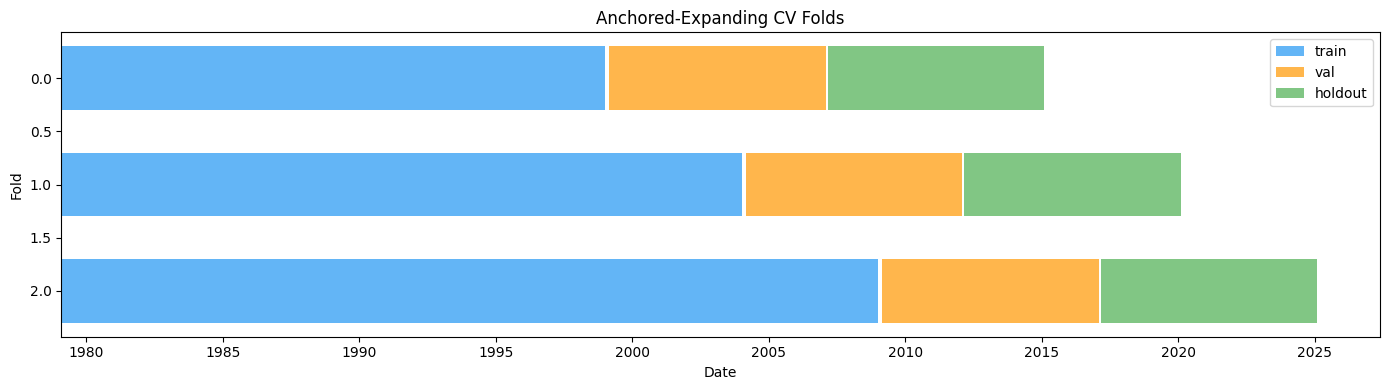

In [266]:
# Gantt chart of CV folds
fig, ax = plt.subplots(figsize=(14, max(4, len(folds) * 0.4)))

colors = {"train": "#2196F3", "val": "#FF9800", "holdout": "#4CAF50"}
dates_sorted = np.sort(model_df["month_end"].unique())
date_min, date_max = dates_sorted[0], dates_sorted[-1]

for f in folds:
    y = f["fold"]
    ax.barh(y, (f["train_end"] - date_min).days, left=0,
            height=0.6, color=colors["train"], alpha=0.7)
    ax.barh(y, (f["val_end"] - f["val_start"]).days,
            left=(f["val_start"] - date_min).days,
            height=0.6, color=colors["val"], alpha=0.7)
    ax.barh(y, (f["holdout_end"] - f["holdout_start"]).days,
            left=(f["holdout_start"] - date_min).days,
            height=0.6, color=colors["holdout"], alpha=0.7)

year_ticks = pd.date_range(date_min, date_max, freq="5YE")
ax.set_xticks([(t - date_min).days for t in year_ticks])
ax.set_xticklabels([t.strftime("%Y") for t in year_ticks])

ax.set_ylabel("Fold")
ax.set_xlabel("Date")
ax.set_title("Anchored-Expanding CV Folds")
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.7, label=l) for l, c in colors.items()]
ax.legend(handles=legend_elements, loc="upper right")
plt.tight_layout()
plt.show()

In [269]:
target_col = "ret_eom_t+1_excess"

def cross_sectional_ic(df, date_col, return_col, pred_col):
    """Average within-month Spearman IC on raw returns."""
    ic_list = []
    for _, group in df.groupby(date_col):
        y = group[return_col].to_numpy()
        p = group[pred_col].to_numpy()
        mask = np.isfinite(y) & np.isfinite(p)
        if mask.sum() < 10:
            continue
        corr, _ = spearmanr(y[mask], p[mask])
        if np.isfinite(corr):
            ic_list.append(corr)
    return float(np.mean(ic_list)) if ic_list else 0.0


def compute_monthly_spreads(
    df, date_col, return_col, pred_col, top_frac=0.10, bottom_frac=0.10
):
    """Top-minus-bottom spread using raw returns within each month."""
    spreads = []
    for _, group in df.groupby(date_col):
        group = group.sort_values(pred_col)
        n = len(group)
        n_top = int(np.floor(n * top_frac))
        n_bot = int(np.floor(n * bottom_frac))
        if n_top < 1 or n_bot < 1:
            continue
        bottom = group.iloc[:n_bot][return_col].mean()
        top = group.iloc[-n_top:][return_col].mean()
        spreads.append(top - bottom)
    return np.asarray(spreads, dtype=np.float64)


def sharpe_ratio(returns, annualization=12):
    returns = np.asarray(returns, dtype=np.float64)
    if returns.size < 3:
        return 0.0
    mean = returns.mean()
    std = returns.std(ddof=0)
    if not np.isfinite(std) or std == 0:
        return 0.0
    return float((mean / std) * np.sqrt(annualization))


def cs_zscore(series: pd.Series) -> pd.Series:
    """Cross-sectional z-score for one month, robust to zero std."""
    values = pd.to_numeric(series, errors="coerce")
    mu = values.mean()
    sigma = values.std(ddof=0)
    if not np.isfinite(sigma) or sigma == 0:
        return pd.Series(np.zeros(len(values), dtype=np.float32), index=series.index)
    z = (values - mu) / sigma
    return z.astype(np.float32)


def compute_cs_features_by_split(
    df,
    split_mask,
    gkx_features,
    macro_features,
    date_col="month_end",
):
    """
    Build split-local features to avoid leakage:
    - c_i,t raw GKX
    - csrank(c_i,t), csnorm(c_i,t) within month and split
    - macro x_t (raw)
    - target z-score (for training objective)
    """
    transformed_suffixes = (
        "_csrank",
        "_csnorm",
        "_zscore",
        "_rank",
        "_quintile",
        "_sector_rel",
        "_sector_rank",
    )

    split_df = df.loc[split_mask].copy()
    drop_cols = [c for c in split_df.columns if c.endswith(transformed_suffixes)]
    if drop_cols:
        split_df = split_df.drop(columns=drop_cols)

    split_df[date_col] = pd.to_datetime(split_df[date_col])

    available_gkx = [c for c in gkx_features if c in split_df.columns]
    available_macro = [c for c in macro_features if c in split_df.columns]

    grouped = split_df.groupby(date_col, sort=False)

    for feat in available_gkx:
        cs_rank = grouped[feat].rank(method="average", pct=True)
        split_df[f"{feat}_csrank"] = cs_rank.astype(np.float32)
        split_df[f"{feat}_csnorm"] = (2.0 * cs_rank - 1.0).astype(np.float32)

    # TODO --- Add in secotor-relative features here ---

    # Compute date-level Z Score for next period returns
    mean = grouped[target_col].transform("mean")
    std = grouped[target_col].transform("std")
    split_df[target_col + "_zscore"] = (split_df[target_col] - mean) / std

    split_df = split_df.replace([np.inf, -np.inf], np.nan)

    out_features = (
        available_gkx
        + [f"{feat}_csrank" for feat in available_gkx]
        + [f"{feat}_csnorm" for feat in available_gkx]
        + available_macro
    )

    return split_df, out_features


def prepare_fold_data_correct(
    model_df, fold_info, gkx_features, macro_features, date_col="month_end"
):
    """
    Prepare fold data while preserving your constraints:
    - csrank/csnorm computed separately in each split
    - train target is z-scored within split month
    - validation metrics are computed on raw returns
    """
    train_mask = fold_info["train_mask"]
    val_mask = fold_info["val_mask"]

    # Hard guard against overlap within this fold
    if np.intersect1d(np.flatnonzero(train_mask), np.flatnonzero(val_mask)).size > 0:
        raise ValueError(f"Fold {fold_info['fold']} has train/val overlap")

    train_df, train_features = compute_cs_features_by_split(
        model_df, train_mask, gkx_features, macro_features, date_col
    )
    val_df, val_features = compute_cs_features_by_split(
        model_df, val_mask, gkx_features, macro_features, date_col
    )

    common_features = [c for c in train_features if c in val_features]
    if not common_features:
        raise ValueError(f"Fold {fold_info['fold']} has no common train/val features")

    X_train = train_df[common_features].to_numpy(dtype=np.float32)
    y_train = train_df[target_col + "_zscore"].to_numpy(dtype=np.float32)
    X_val = val_df[common_features].to_numpy(dtype=np.float32)
    y_val = val_df[target_col + "_zscore"].to_numpy(dtype=np.float32)

    target_cols = list({"ret_eom_t+1", target_col, target_col + "_zscore"})
    val_df_meta = val_df[["ticker", date_col, *target_cols]].copy()

    fold_diag = {
        "fold": int(fold_info["fold"]),
        "train_rows": int(len(train_df)),
        "val_rows": int(len(val_df)),
        "n_features": int(len(common_features)),
        "train_months": int(train_df[date_col].nunique()),
        "val_months": int(val_df[date_col].nunique()),
    }

    return X_train, y_train, X_val, y_val, val_df_meta, common_features, fold_diag


def evaluate_params_on_folds(params, fold_list, verbose=False):
    """Train XGBoost across folds with split-local CS features and z-score target."""
    fold_mse = []
    fold_spreads = []
    fold_cs_ic = []
    fold_best_iter = []
    fold_feature_counts = []
    fold_row_counts = []

    for fold_info in fold_list:
        X_tr, y_tr, X_va, y_va, val_df_meta, fold_features, fold_diag = (
            prepare_fold_data_correct(
                model_df,
                fold_info,
                raw_gkx_cols,
                macro_feature_cols,
                date_col="month_end",
            )
        )

        dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=fold_features)
        dval = xgb.DMatrix(X_va, label=y_va, feature_names=fold_features)

        full_params = {
            "objective": "reg:pseudohubererror",
            "tree_method": "hist",
            "nthread": 3,
            **params,
        }

        model = xgb.train(
            full_params,
            dtrain,
            num_boost_round=1000,
            evals=[(dval, "valid")],
            early_stopping_rounds=30,
            verbose_eval=False,
        )

        preds = model.predict(dval)
        val_df_meta["pred"] = preds

        fold_mse.append(float(model.best_score))
        fold_best_iter.append(int(model.best_iteration))
        fold_cs_ic.append(cross_sectional_ic(val_df_meta, "month_end", target_col, "pred"))
        fold_spreads.append(
            compute_monthly_spreads(val_df_meta, "month_end", target_col, "pred")
        )
        fold_feature_counts.append(fold_diag["n_features"])
        fold_row_counts.append((fold_diag["train_rows"], fold_diag["val_rows"]))

        if verbose:
            print(
                f"Fold {fold_info['fold']}: train={fold_diag['train_rows']}, "
                f"val={fold_diag['val_rows']}, features={fold_diag['n_features']}, "
                f"CS-IC={fold_cs_ic[-1]:.4f}"
            )

    return {
        "fold_mse": fold_mse,
        "fold_spreads": fold_spreads,
        "fold_cs_ic": fold_cs_ic,
        "fold_best_iter": fold_best_iter,
        "fold_feature_counts": fold_feature_counts,
        "fold_row_counts": fold_row_counts,
    }


def score_fold_spreads(fold_spreads):
    """Sharpe per fold, then average."""
    fold_sharpes = [sharpe_ratio(s) for s in fold_spreads if len(s) >= 3]
    return float(np.mean(fold_sharpes)) if fold_sharpes else 0.0


In [270]:
# Quick sanity check of the split-local feature/target pipeline
_fold0 = folds[0]
X_tr0, y_tr0, X_va0, y_va0, va_meta0, feat0, diag0 = prepare_fold_data_correct(
    model_df,
    _fold0,
    raw_gkx_cols,
    macro_feature_cols,
    date_col="month_end",
)

fold0_checks = pd.Series(
    {
        "fold": diag0["fold"],
        "train_rows": diag0["train_rows"],
        "val_rows": diag0["val_rows"],
        "n_features": diag0["n_features"],
        "train_months": diag0["train_months"],
        "val_months": diag0["val_months"],
        "train_target_mean": float(np.nanmean(y_tr0)),
        "train_target_std": float(np.nanstd(y_tr0)),
        "val_raw_ret_mean": float(va_meta0["ret_eom_t+1"].mean()),
        "val_raw_ret_std": float(va_meta0["ret_eom_t+1"].std(ddof=0)),
    }
)
print(fold0_checks.to_string())


C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\2549912431.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csrank"] = cs_rank.astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\2549912431.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csnorm"] = (2.0 * cs_rank - 1.0).astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\2549912431.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

fold                 0.000000e+00
train_rows           1.626640e+05
val_rows             1.341900e+05
n_features           3.010000e+02
train_months         2.400000e+02
val_months           9.600000e+01
train_target_mean    1.988678e-08
train_target_std     9.992620e-01
val_raw_ret_mean     1.237834e-02
val_raw_ret_std      1.176946e-01


---
## Phase 1: Random Search (Landscape Exploration)

Broad grid, random sample of configs, evaluated on a random subset of folds.
Goal: understand which hyperparameter ranges matter and narrow the space.

In [278]:
# Broad search space
grid_values = dict(
    max_depth=[2, 4, 6],
    learning_rate=[0.01, 0.025],
    subsample=[0.40, 0.60, 0.80],
    colsample_bytree=[0.4, 0.60, 0.8],
    min_child_weight=[1, 50, 100],
    alpha=[0.1, 1.0, 5.0],
)

param_grid = [
    dict(zip(grid_values.keys(), vals))
    for vals in product(*grid_values.values())
]
print(f"Full grid size: {len(param_grid)}")

# Random sample of configs for Phase 1
N_RANDOM = min(25, len(param_grid))
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(param_grid), size=N_RANDOM, replace=False)
sampled_configs = [param_grid[i] for i in sample_idx]

# Random subset of folds for fast screening
N_FOLDS_P1 = min(3, len(folds))
fold_idx = rng.choice(len(folds), size=N_FOLDS_P1, replace=False)
p1_folds = [folds[i] for i in sorted(fold_idx)]
print(f"Phase 1: {N_RANDOM} configs x {N_FOLDS_P1} folds (folds {sorted(fold_idx)})")


Full grid size: 486
Phase 1: 25 configs x 3 folds (folds [np.int32(0), np.int32(1), np.int32(2)])


### Run Phase 1 using parallel trials

In [279]:
%%time

N_CORES = multiprocessing.cpu_count()

import os

os.environ["OMP_NUM_THREADS"] = "3"

N_PARALLEL = min(4, max(1, N_CORES // 2))


def evaluate_single_config(params, idx):
    results = evaluate_params_on_folds(params, p1_folds, verbose=False)

    avg_best_iter = float(np.mean(results["fold_best_iter"])) if results["fold_best_iter"] else 0.0
    min_best_iter = int(np.min(results["fold_best_iter"])) if results["fold_best_iter"] else 0
    mean_mse = float(np.mean(results["fold_mse"])) if results["fold_mse"] else np.nan
    std_mse = float(np.std(results["fold_mse"])) if results["fold_mse"] else np.nan
    spread_sharpe = score_fold_spreads(results["fold_spreads"])
    mean_cs_ic = float(np.mean(results["fold_cs_ic"])) if results["fold_cs_ic"] else np.nan

    all_spreads = np.concatenate(results["fold_spreads"]) if results["fold_spreads"] else np.array([])
    result = {
        **params,
        "avg_best_iter": avg_best_iter,
        "min_best_iter": min_best_iter,
        "mean_feature_count": float(np.mean(results["fold_feature_counts"])),
        "cs_ic": mean_cs_ic,
        "mean_mse": mean_mse,
        "std_mse": std_mse,
        "spread_sharpe": spread_sharpe,
        "mean_spread": float(np.mean(all_spreads)) if len(all_spreads) > 0 else 0.0,
        "std_spread": float(np.std(all_spreads)) if len(all_spreads) > 0 else 0.0,
    }

    print(f"[{idx+1}/{N_RANDOM}] MSE={mean_mse:.4f}  CS-IC={mean_cs_ic:.4f}")
    return result


p1_results = Parallel(n_jobs=N_PARALLEL, backend="loky")(
    delayed(evaluate_single_config)(params, i) for i, params in enumerate(sampled_configs)
)

p1_df = pd.DataFrame(p1_results).sort_values("cs_ic", ascending=False)

print("\nTop 10 configs (sorted by CS-IC):")
print(p1_df.head(10).to_string(index=False))


c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Top 10 configs (sorted by CS-IC):
 max_depth  learning_rate  subsample  colsample_bytree  min_child_weight  alpha  avg_best_iter  min_best_iter  mean_feature_count    cs_ic  mean_mse  std_mse  spread_sharpe  mean_spread  std_spread
         2          0.010        0.4               0.6                 1    0.1     271.666667            247               301.0 0.051071  0.323842 0.002222       1.792823     0.018429    0.036159
         2          0.025        0.4               0.4                50    0.1     101.333333             84               301.0 0.050723  0.323841 0.002257       1.783086     0.018497    0.036501
         2          0.025        0.4               0.8                 1    5.0     131.333333            123               301.0 0.049766  0.323827 0.002236       1.756322     0.018587    0.036976
         2          0.025        0.4               0.8                50    5.0     132.000000            123               301.0 0.049079  0.323827 0.002255       1.732219 

### Plot results from 1st phase

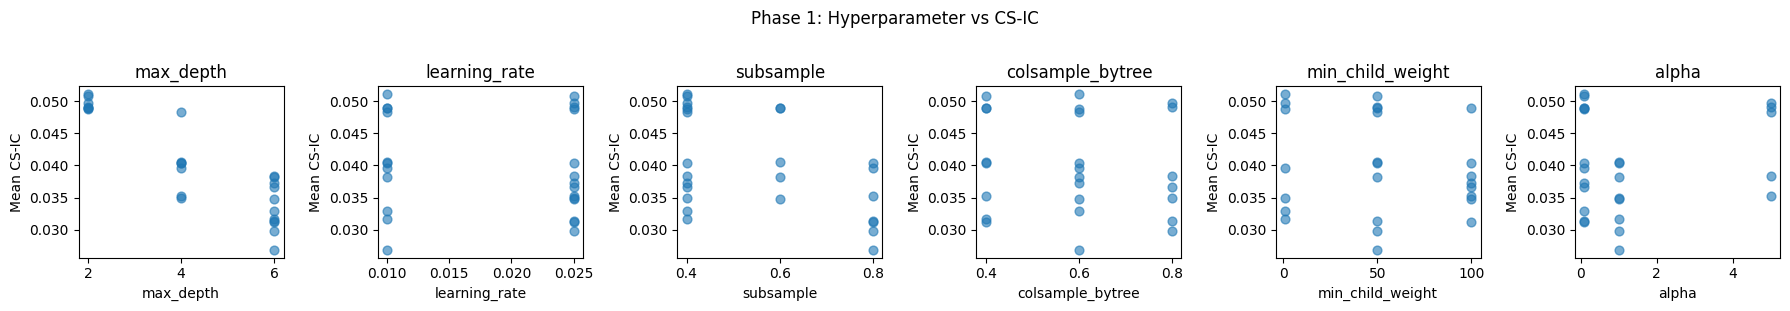

In [282]:
# Scatter plots: CS-IC vs each hyperparameter
hp_names = list(grid_values.keys())
fig, axes = plt.subplots(1, len(hp_names), figsize=(3 * len(hp_names), 3))

for ax, hp in zip(axes, hp_names):
    ax.scatter(p1_df[hp], p1_df["cs_ic"], alpha=0.6, s=40)
    ax.set_xlabel(hp)
    ax.set_ylabel("Mean CS-IC")
    ax.set_title(hp)

fig.suptitle("Phase 1: Hyperparameter vs CS-IC", y=1.02)
plt.tight_layout()
plt.show()

C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\2911029133.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\2911029133.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\2911029133.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440

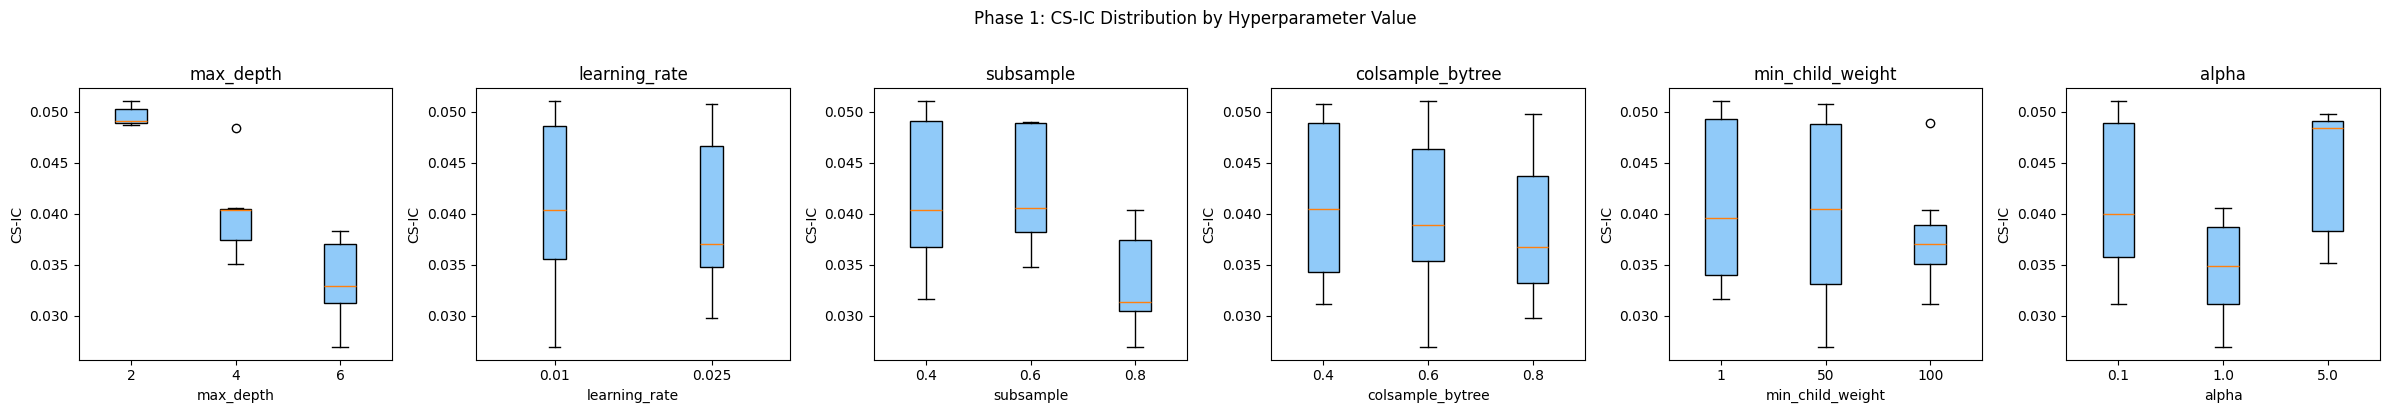

In [281]:
# Box plots: CS-IC distribution by hyperparameter value
fig, axes = plt.subplots(1, len(hp_names), figsize=(4 * len(hp_names), 4))

for ax, hp in zip(axes, hp_names):
    unique_vals = sorted(p1_df[hp].unique())
    data = [p1_df.loc[p1_df[hp] == v, "cs_ic"].values for v in unique_vals]
    bp = ax.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#90CAF9")
    ax.set_xlabel(hp)
    ax.set_ylabel("CS-IC")
    ax.set_title(hp)

fig.suptitle("Phase 1: CS-IC Distribution by Hyperparameter Value", y=1.02)
plt.tight_layout()
plt.show()

### Narrow the search space

Based on the Phase 1 scatter/box plots above, update the ranges below
to focus on the promising region before running Bayesian optimization.

In [283]:
# Refine space after inspecting plots above
NARROWED_SPACE = {
    "max_depth": (1, 3),              # (low, high) integer
    "learning_rate": (0.005, 0.0125), # (low, high) log-uniform
    "subsample": (0.30, 0.70),        # (low, high) uniform
    "colsample_bytree": (0.35, 0.65), # (low, high) uniform
    "min_child_weight": (1, 10),      # (low, high) integer

    # Add new params
    "lambda": (0.001, 2.0), 
    "alpha": (0.1, 0.5)
}

print("Narrowed search space for Phase 2:")
for k, v in NARROWED_SPACE.items():
    print(f"  {k}: {v}")

Narrowed search space for Phase 2:
  max_depth: (1, 3)
  learning_rate: (0.005, 0.0125)
  subsample: (0.3, 0.7)
  colsample_bytree: (0.35, 0.65)
  min_child_weight: (1, 10)
  lambda: (0.001, 2.0)
  alpha: (0.1, 0.5)


---
## Phase 2: Bayesian Optimization (All Folds)

Optuna TPE sampler explores the narrowed space efficiently.
Each trial is evaluated on ALL folds for robust estimation.

In [284]:
%%time 

N_TRIALS = 20


def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", *NARROWED_SPACE["max_depth"]),
        "learning_rate": trial.suggest_float(
            "learning_rate", *NARROWED_SPACE["learning_rate"], log=True
        ),
        "subsample": trial.suggest_float("subsample", *NARROWED_SPACE["subsample"]),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", *NARROWED_SPACE["colsample_bytree"]
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", *NARROWED_SPACE["min_child_weight"]
        ),
        "alpha": trial.suggest_float("alpha", *NARROWED_SPACE["alpha"]),
        "lambda": trial.suggest_float("lambda", *NARROWED_SPACE["lambda"]),
        "nthread": 3,
    }

    results = evaluate_params_on_folds(params, folds, verbose=False)

    mean_mse = float(np.mean(results["fold_mse"])) if results["fold_mse"] else np.nan
    spread_sharpe = score_fold_spreads(results["fold_spreads"])
    mean_cs_ic = float(np.mean(results["fold_cs_ic"])) if results["fold_cs_ic"] else np.nan
    std_cs_ic = float(np.std(results["fold_cs_ic"])) if results["fold_cs_ic"] else np.nan
    icir = mean_cs_ic / std_cs_ic if np.isfinite(std_cs_ic) and std_cs_ic > 0 else np.nan

    all_spreads = np.concatenate(results["fold_spreads"]) if results["fold_spreads"] else np.array([])

    trial.set_user_attr("mean_spread", float(np.mean(all_spreads)) if len(all_spreads) > 0 else 0.0)
    trial.set_user_attr("spread_sharpe", float(spread_sharpe))
    trial.set_user_attr(
        "per_fold_spread_sharpe",
        [round(float(sharpe_ratio(s)), 4) for s in results["fold_spreads"]],
    )

    trial.set_user_attr("mean_cs_ic", float(mean_cs_ic))
    trial.set_user_attr("icir", float(icir) if np.isfinite(icir) else np.nan)
    trial.set_user_attr("per_fold_cs_ic", [round(float(ic), 4) for ic in results["fold_cs_ic"]])

    trial.set_user_attr("mean_mse", float(mean_mse))
    trial.set_user_attr("per_fold_mse", [round(float(m), 6) for m in results["fold_mse"]])

    trial.set_user_attr("per_fold_best_iter", [int(n) for n in results["fold_best_iter"]])
    trial.set_user_attr("mean_best_iter", float(np.mean(results["fold_best_iter"])))

    trial.set_user_attr("per_fold_feature_count", [int(n) for n in results["fold_feature_counts"]])

    return mean_cs_ic


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="xgb_tuning_phase2",
)

# Seed with best Phase 1 config
best_p1 = p1_df.iloc[0]
study.enqueue_trial(
    {
        "max_depth": int(best_p1["max_depth"]),
        "learning_rate": float(best_p1["learning_rate"]),
        "subsample": float(best_p1["subsample"]),
        "colsample_bytree": float(best_p1["colsample_bytree"]),
        "min_child_weight": int(best_p1["min_child_weight"]),
        "alpha": float(best_p1["alpha"]),
        "lambda": 1.0,
    }
)

print(
    f"Running {N_TRIALS} Bayesian trials on all {len(folds)} folds ({N_PARALLEL} parallel)..."
)
print("Objective: mean validation CS-IC on raw returns (maximize)")
study.optimize(objective, n_trials=N_TRIALS, n_jobs=N_PARALLEL, show_progress_bar=True)

print(f"\nBest trial #{study.best_trial.number}:")
print(f"  CS-IC:         {study.best_value:.4f}")
print(f"  Mean MSE:      {study.best_trial.user_attrs['mean_mse']:.6f}")
print(f"  Spread Sharpe: {study.best_trial.user_attrs['spread_sharpe']:.3f}")
print(f"  Mean spread:   {study.best_trial.user_attrs['mean_spread']:.4f}")
print(f"  Mean trees:    {study.best_trial.user_attrs['mean_best_iter']:.0f}")
print(f"  Params:        {study.best_params}")


Running 20 Bayesian trials on all 3 folds (4 parallel)...
Objective: mean validation CS-IC on raw returns (maximize)


  0%|          | 0/20 [00:00<?, ?it/s]C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\2549912431.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csrank"] = cs_rank.astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\2549912431.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csnorm"] = (2.0 * cs_rank - 1.0).astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\2549912431.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the r


Best trial #15:
  CS-IC:         0.0544
  Mean MSE:      0.323777
  Spread Sharpe: 1.812
  Mean spread:   0.0187
  Mean trees:    563
  Params:        {'max_depth': 1, 'learning_rate': 0.01222129727518258, 'subsample': 0.32286399225197177, 'colsample_bytree': 0.6425298795894355, 'min_child_weight': 3, 'alpha': 0.49733523398070556, 'lambda': 0.03765186812789506}
CPU times: total: 1h 17min 30s
Wall time: 27min 17s


In [286]:
study.trials_dataframe().sort_values("user_attrs_mean_cs_ic", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_alpha,params_colsample_bytree,params_lambda,params_learning_rate,params_max_depth,...,user_attrs_mean_mse,user_attrs_mean_spread,user_attrs_per_fold_best_iter,user_attrs_per_fold_cs_ic,user_attrs_per_fold_feature_count,user_attrs_per_fold_mse,user_attrs_per_fold_spread_sharpe,user_attrs_spread_sharpe,system_attrs_fixed_params,state
15,15,0.054440,2026-03-30 19:59:35.091388,2026-03-30 20:05:37.933474,0 days 00:06:02.842086,0.497335,0.642530,0.037652,0.012221,1,...,0.323777,0.018714,"[456, 823, 411]","[0.0635, 0.0512, 0.0486]","[301, 301, 301]","[0.323896, 0.326432, 0.321005]","[1.9358, 1.6205, 1.8805]",1.812255,NaN,COMPLETE
4,4,0.054311,2026-03-30 19:45:22.627456,2026-03-30 19:51:13.849300,0 days 00:05:51.221844,0.495887,0.508166,0.417205,0.008623,1,...,0.323778,0.018600,"[785, 983, 567]","[0.0647, 0.0498, 0.0485]","[301, 301, 301]","[0.323848, 0.326461, 0.321025]","[2.0022, 1.5906, 1.8228]",1.805184,NaN,COMPLETE
3,3,0.053895,2026-03-30 19:42:04.479067,2026-03-30 19:48:34.172910,0 days 00:06:29.693843,0.376694,0.614230,1.956047,0.007135,1,...,0.323796,0.018262,"[876, 983, 881]","[0.0639, 0.0486, 0.0492]","[301, 301, 301]","[0.323899, 0.326512, 0.320979]","[1.9572, 1.5598, 1.9276]",1.814847,NaN,COMPLETE
19,19,0.053817,2026-03-30 20:05:37.945098,2026-03-30 20:09:22.020563,0 days 00:03:44.075465,0.426664,0.649623,0.334018,0.009166,1,...,0.323800,0.017976,"[643, 983, 478]","[0.0637, 0.0502, 0.0476]","[301, 301, 301]","[0.323889, 0.326449, 0.321062]","[1.9237, 1.5638, 1.7323]",1.739902,NaN,COMPLETE
14,14,0.053811,2026-03-30 19:56:32.035894,2026-03-30 20:03:25.946520,0 days 00:06:53.910626,0.482449,0.355747,0.141050,0.011662,1,...,0.323789,0.018033,"[505, 734, 467]","[0.0631, 0.0488, 0.0495]","[301, 301, 301]","[0.323921, 0.326491, 0.320954]","[1.8612, 1.6412, 1.7884]",1.763624,NaN,COMPLETE
18,18,0.053595,2026-03-30 20:03:25.954269,2026-03-30 20:09:07.121082,0 days 00:05:41.166813,0.418829,0.643813,1.050424,0.006910,1,...,0.323800,0.017953,"[806, 995, 957]","[0.0631, 0.0482, 0.0494]","[301, 301, 301]","[0.32391, 0.326525, 0.320964]","[1.9393, 1.5018, 1.9666]",1.802588,NaN,COMPLETE
13,13,0.053403,2026-03-30 19:54:23.232218,2026-03-30 20:01:12.258319,0 days 00:06:49.026101,0.499102,0.460852,0.053841,0.012024,1,...,0.323791,0.017912,"[505, 511, 463]","[0.0636, 0.0474, 0.0493]","[301, 301, 301]","[0.323894, 0.326518, 0.32096]","[1.9364, 1.5024, 1.9324]",1.790357,NaN,COMPLETE
17,17,0.053089,2026-03-30 20:02:35.432987,2026-03-30 20:08:47.597625,0 days 00:06:12.164638,0.469379,0.375691,0.122337,0.006759,1,...,0.323822,0.017192,"[915, 993, 810]","[0.0632, 0.0471, 0.049]","[301, 301, 301]","[0.323917, 0.326558, 0.320992]","[1.8762, 1.4082, 1.8048]",1.696433,NaN,COMPLETE
16,16,0.052556,2026-03-30 20:01:12.270139,2026-03-30 20:08:32.721401,0 days 00:07:20.451262,0.493472,0.351536,0.026479,0.005810,1,...,0.323847,0.016641,"[931, 993, 999]","[0.0627, 0.0458, 0.0492]","[301, 301, 301]","[0.323948, 0.3266, 0.320992]","[1.8014, 1.2853, 1.8764]",1.654332,NaN,COMPLETE
11,11,0.052098,2026-03-30 19:52:20.488633,2026-03-30 20:02:35.426852,0 days 00:10:14.938219,0.301765,0.528690,1.483794,0.005533,1,...,0.323877,0.016307,"[919, 999, 999]","[0.0619, 0.0456, 0.0489]","[301, 301, 301]","[0.32398, 0.326622, 0.321029]","[1.8046, 1.309, 1.8131]",1.642217,NaN,COMPLETE


### Phase 2 Analysis

In [287]:
# Trial history
trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df["state"] == "COMPLETE"].sort_values("value", ascending=False)

display_cols = ["number", "value"] + [c for c in trials_df.columns if c.startswith("params_")]
print("Top 10 trials (value = mean CS-IC):")
print(trials_df[display_cols].head(10).to_string(index=False))

Top 10 trials (value = mean CS-IC):
 number    value  params_alpha  params_colsample_bytree  params_lambda  params_learning_rate  params_max_depth  params_min_child_weight  params_subsample
     15 0.054440      0.497335                 0.642530       0.037652              0.012221                 1                        3          0.322864
      4 0.054311      0.495887                 0.508166       0.417205              0.008623                 1                        3          0.367597
      3 0.053895      0.376694                 0.614230       1.956047              0.007135                 1                        7          0.435580
     19 0.053817      0.426664                 0.649623       0.334018              0.009166                 1                        3          0.379437
     14 0.053811      0.482449                 0.355747       0.141050              0.011662                 1                        7          0.307975
     18 0.053595      0.418829          

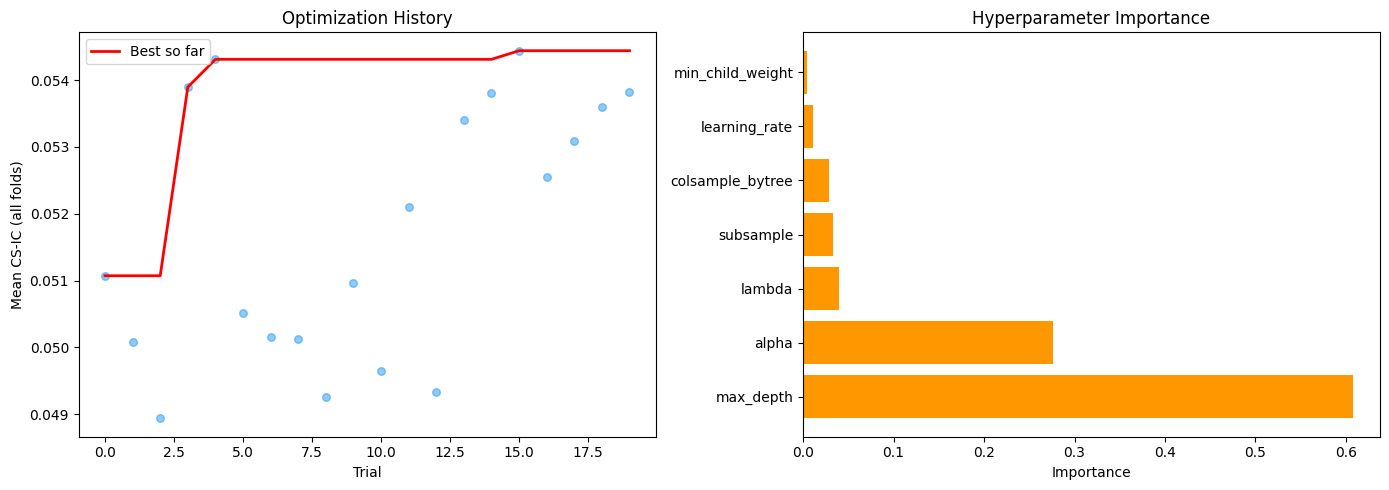

In [288]:
# Optimization history: CS-IC over trials
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_nums = [t.number for t in completed]
trial_vals = [t.value for t in completed]
ax.scatter(trial_nums, trial_vals, alpha=0.5, s=30, color="#2196F3")
running_best = np.maximum.accumulate(trial_vals)
ax.plot(trial_nums, running_best, color="red", linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Mean CS-IC (all folds)")
ax.set_title("Optimization History")
ax.legend()

# Hyperparameter importance
ax = axes[1]
try:
    importance = optuna.importance.get_param_importances(study)
    ax.barh(list(importance.keys()), list(importance.values()), color="#FF9800")
    ax.set_xlabel("Importance")
    ax.set_title("Hyperparameter Importance")
except Exception:
    ax.text(
        0.5,
        0.5,
        "Need more trials for importance",
        ha="center",
        va="center",
        transform=ax.transAxes,
    )

plt.tight_layout()
plt.show()


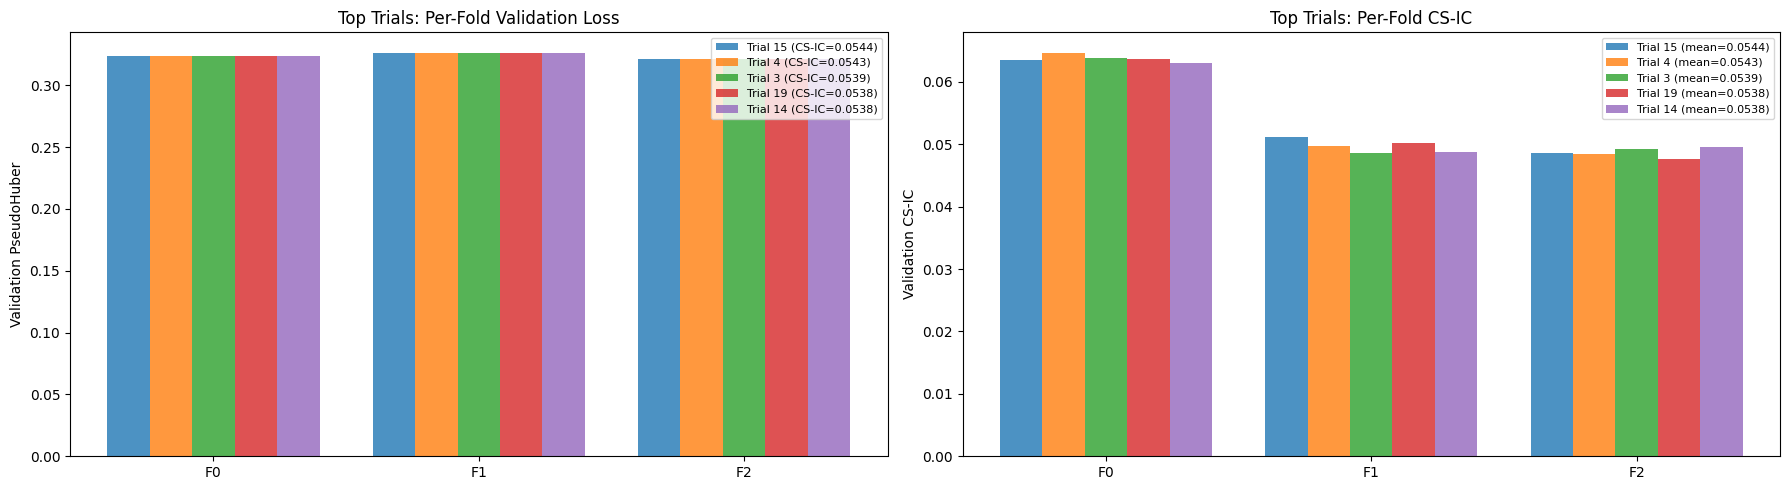

In [289]:
# Per-fold metrics for top 5 trials
top_trials = sorted(
    [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
    key=lambda t: t.value,
    reverse=True,
)[:5]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Per-fold validation loss
ax = axes[0]
n_top = len(top_trials)
x = np.arange(len(folds))
width = 0.8 / max(n_top, 1)

for i, trial in enumerate(top_trials):
    fold_mse = trial.user_attrs["per_fold_mse"]
    offset = (i - n_top / 2 + 0.5) * width
    ax.bar(
        x + offset,
        fold_mse,
        width,
        label=f"Trial {trial.number} (CS-IC={trial.value:.4f})",
        alpha=0.8,
    )

ax.set_xticks(x)
ax.set_xticklabels([f"F{i}" for i in range(len(folds))])
ax.set_ylabel("Validation PseudoHuber")
ax.set_title("Top Trials: Per-Fold Validation Loss")
ax.legend(fontsize=8)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

# Per-fold validation CS-IC
ax = axes[1]
for i, trial in enumerate(top_trials):
    fold_cs_ic = trial.user_attrs["per_fold_cs_ic"]
    offset = (i - n_top / 2 + 0.5) * width
    ax.bar(
        x + offset,
        fold_cs_ic,
        width,
        label=f"Trial {trial.number} (mean={trial.user_attrs['mean_cs_ic']:.4f})",
        alpha=0.8,
    )

ax.set_xticks(x)
ax.set_xticklabels([f"F{i}" for i in range(len(folds))])
ax.set_ylabel("Validation CS-IC")
ax.set_title("Top Trials: Per-Fold CS-IC")
ax.legend(fontsize=8)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()


## Holdout Evaluation with Best Params

In [290]:
best_params = dict(study.best_params)
best_params

{'max_depth': 1,
 'learning_rate': 0.01222129727518258,
 'subsample': 0.32286399225197177,
 'colsample_bytree': 0.6425298795894355,
 'min_child_weight': 3,
 'alpha': 0.49733523398070556,
 'lambda': 0.03765186812789506}

In [174]:
# best_trial = study.trials_dataframe().query("number == 9")

# best_params = {
#     col.replace("params_", ""): best_trial[col].iloc[0] 
#     for col in best_trial 
#     if col.startswith("params_")
# }

# def normalize_types(d):
#     return {
#         k: v.item() if isinstance(v, np.generic) else v
#         for k, v in d.items()
#     }

# best_params = normalize_types(best_params)

# best_params

In [298]:
target_cols = ["ret_eom_t+1", "ret_eom_t+1_excess_zscore"]

In [299]:
def pseudohuber_loss(y_true, y_pred, delta=1.0):
    r = y_true - y_pred
    return float(np.mean(delta ** 2 * (np.sqrt(1 + (r / delta) ** 2) - 1)))


print(f"Evaluating best params on all holdout sets: {best_params}\n")

holdout_metrics = []
holdout_predictions = []
holdout_feature_checks = []

last_model = None
last_holdout_frame = None
last_feature_cols = None

for fold_info in folds:
    train_mask = fold_info["train_mask"]
    val_mask = fold_info["val_mask"]
    holdout_mask = fold_info["holdout_mask"]

    X_tr, y_tr, X_va, y_va, _, fold_features, fold_diag = prepare_fold_data_correct(
        model_df,
        fold_info,
        raw_gkx_cols,
        macro_feature_cols,
        date_col="month_end",
    )

    holdout_split_df, holdout_features = compute_cs_features_by_split(
        model_df,
        holdout_mask,
        raw_gkx_cols,
        macro_feature_cols,
        date_col="month_end",
    )

    common_features = [c for c in fold_features if c in holdout_features]
    if not common_features:
        print(f"  Fold {fold_info['fold']}: skipped (no common features)")
        continue

    # Re-materialize arrays on common feature set for strict alignment
    train_df, _ = compute_cs_features_by_split(
        model_df,
        train_mask,
        raw_gkx_cols,
        macro_feature_cols,
        date_col="month_end",
    )
    val_df, _ = compute_cs_features_by_split(
        model_df,
        val_mask,
        raw_gkx_cols,
        macro_feature_cols,
        date_col="month_end",
    )

    X_tr = train_df[common_features].to_numpy(dtype=np.float32)
    y_tr = train_df[target_col].to_numpy(dtype=np.float32)
    X_va = val_df[common_features].to_numpy(dtype=np.float32)
    y_va = val_df[target_col].to_numpy(dtype=np.float32)

    X_ho = holdout_split_df[common_features].to_numpy(dtype=np.float32)
    y_ho_z = holdout_split_df[target_col].to_numpy(dtype=np.float32)

    full_params = {
        "objective": "reg:pseudohubererror",
        "tree_method": "hist",
        "nthread": 3,
        **best_params,
    }

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=common_features)
    dval = xgb.DMatrix(X_va, label=y_va, feature_names=common_features)
    dho = xgb.DMatrix(X_ho, feature_names=common_features)

    model = xgb.train(
        full_params,
        dtrain,
        num_boost_round=1000,
        evals=[(dval, "valid")],
        early_stopping_rounds=30,
        verbose_eval=False,
    )

    preds = model.predict(dho)
    last_model = model
    last_holdout_frame = holdout_split_df.copy()
    last_holdout_frame["pred"] = preds
    last_feature_cols = common_features

    f_phuber = pseudohuber_loss(y_ho_z, preds, delta=1.0)

    ho_df = holdout_split_df[
        ["ticker", "month_end", *target_cols]
    ].copy()
    ho_df["pred"] = preds

    cs_ic = cross_sectional_ic(ho_df, "month_end", target_col.replace("_zscore", ""), "pred")
    spreads = compute_monthly_spreads(ho_df, "month_end", target_col.replace("_zscore", ""), "pred")
    spread_sharpe = sharpe_ratio(spreads) if len(spreads) >= 3 else 0.0
    mean_spread = float(np.mean(spreads)) if len(spreads) > 0 else np.nan

    holdout_metrics.append(
        {
            "fold": fold_info["fold"],
            "holdout_start": fold_info["holdout_start"].strftime("%Y-%m"),
            "holdout_end": fold_info["holdout_end"].strftime("%Y-%m"),
            "fold_phuber": f_phuber,
            "cs_ic": cs_ic,
            "mean_spread": mean_spread,
            "spread_sharpe": spread_sharpe,
            "n_holdout": int(holdout_mask.sum()),
        }
    )

    holdout_feature_checks.append(
        {
            "fold": fold_info["fold"],
            "n_common_features": len(common_features),
            "train_rows": len(train_df),
            "val_rows": len(val_df),
            "holdout_rows": len(holdout_split_df),
            "best_iteration": int(model.best_iteration),
            "best_score": float(model.best_score),
        }
    )

    holdout_predictions.append(ho_df.assign(fold=fold_info["fold"]))

    print(
        f"  Fold {fold_info['fold']}: "
        f"PseudoHuber={f_phuber:.6f}, "
        f"CS-IC={cs_ic:.4f}, "
        f"Spread={mean_spread:.4f}, "
        f"Sharpe={spread_sharpe:.2f}, "
    )

holdout_metrics_df = pd.DataFrame(holdout_metrics)
holdout_feature_checks_df = pd.DataFrame(holdout_feature_checks)
holdout_pred_df = (
    pd.concat(holdout_predictions, ignore_index=True) if holdout_predictions else pd.DataFrame()
)

print("\nHoldout summary:")
print(
    f"Mean holdout PseudoHuber: {holdout_metrics_df['fold_phuber'].mean():.6f} "
    f"(std={holdout_metrics_df['fold_phuber'].std():.6f})"
)
print(
    f"Mean holdout CS-IC:       {holdout_metrics_df['cs_ic'].mean():.4f} "
    f"(std={holdout_metrics_df['cs_ic'].std():.4f})"
)
print(f"Mean holdout spread:      {holdout_metrics_df['mean_spread'].mean():.4f}")
print(f"Mean holdout spread SR:   {holdout_metrics_df['spread_sharpe'].mean():.2f}")


Evaluating best params on all holdout sets: {'max_depth': 1, 'learning_rate': 0.01222129727518258, 'subsample': 0.32286399225197177, 'colsample_bytree': 0.6425298795894355, 'min_child_weight': 3, 'alpha': 0.49733523398070556, 'lambda': 0.03765186812789506}



C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\2549912431.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csrank"] = cs_rank.astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\2549912431.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csnorm"] = (2.0 * cs_rank - 1.0).astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\2549912431.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

KeyError: 'ret_eom_t+1_excess'

In [ ]:
holdout_metrics_df.head(10)


,fold,holdout_start,holdout_end,fold_phuber,cs_ic,mean_spread,spread_sharpe,n_holdout
0,0,2007-02,2014-01,0.005554,0.037815,0.020964,1.514333,147863
1,1,2012-02,2019-01,0.004330,0.026790,0.011473,1.226209,178414
2,2,2017-02,2024-01,0.007008,0.000280,0.006072,0.364331,225117


In [130]:
print("Feature/fit checks by fold:")
print(holdout_feature_checks_df.to_string(index=False))
holdout_pred_df.head(10)


Feature/fit checks by fold:
 fold  n_common_features  train_rows  val_rows  holdout_rows  best_iteration  best_score
    0                301      162664    114910        147863             743    0.006137
    1                301      241285    138280        178414             998    0.005584
    2                301      336542    164913        225117             167    0.004251


,ticker,month_end,ret_eom_t+1,res_ret_eom_t+1,res_ret_eom_t+1_zscore,pred,fold
0,A,2007-02-28,0.061102,0.052969,0.725049,-0.000722,0
1,A,2007-03-31,0.020184,-0.009865,-0.128730,-0.004258,0
2,A,2007-04-30,0.110562,0.078071,0.985986,-0.004641,0
3,A,2007-05-31,0.007074,0.018345,0.254595,-0.002704,0
4,A,2007-06-30,-0.007544,0.037683,0.419843,-0.003467,0
5,A,2007-07-31,-0.045872,-0.052351,-0.551546,-0.003330,0
6,A,2007-08-31,0.013187,-0.016369,-0.174223,-0.003276,0
7,A,2007-09-30,-0.000814,-0.028383,-0.280013,-0.003562,0
8,A,2007-10-31,0.026594,0.091841,0.949060,-0.005676,0
9,A,2007-11-30,-0.028813,-0.018523,-0.191636,-0.004657,0


## Diagnostic Plots

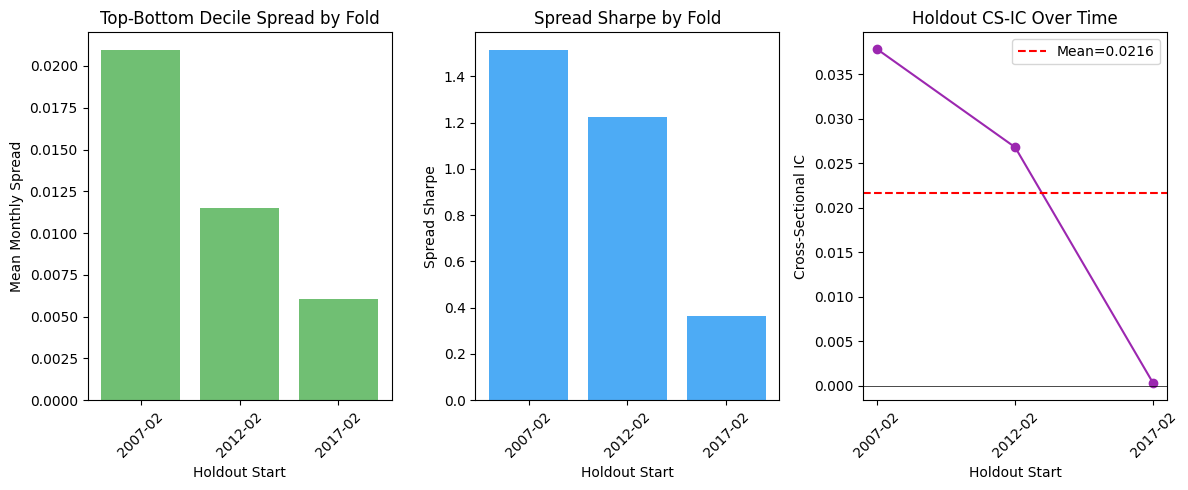

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Row 1: spread, spread Sharpe
ax = axes[0]
ax.bar(
    holdout_metrics_df["holdout_start"],
    holdout_metrics_df["mean_spread"],
    color=["#4CAF50" if s > 0 else "#f44336" for s in holdout_metrics_df["mean_spread"]],
    alpha=0.8,
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Holdout Start")
ax.set_ylabel("Mean Monthly Spread")
ax.set_title("Top-Bottom Decile Spread by Fold")
ax.tick_params(axis="x", rotation=45)

ax = axes[1]
ax.bar(
    holdout_metrics_df["holdout_start"],
    holdout_metrics_df["spread_sharpe"],
    color=["#2196F3" if s > 0 else "#f44336" for s in holdout_metrics_df["spread_sharpe"]],
    alpha=0.8,
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Holdout Start")
ax.set_ylabel("Spread Sharpe")
ax.set_title("Spread Sharpe by Fold")
ax.tick_params(axis="x", rotation=45)

# CS-IC
ax = axes[2]
ax.plot(holdout_metrics_df["holdout_start"], holdout_metrics_df["cs_ic"], "o-", color="#9C27B0")
ax.axhline(
    holdout_metrics_df["cs_ic"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean={holdout_metrics_df['cs_ic'].mean():.4f}",
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Holdout Start")
ax.set_ylabel("Cross-Sectional IC")
ax.set_title("Holdout CS-IC Over Time")
ax.legend()
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

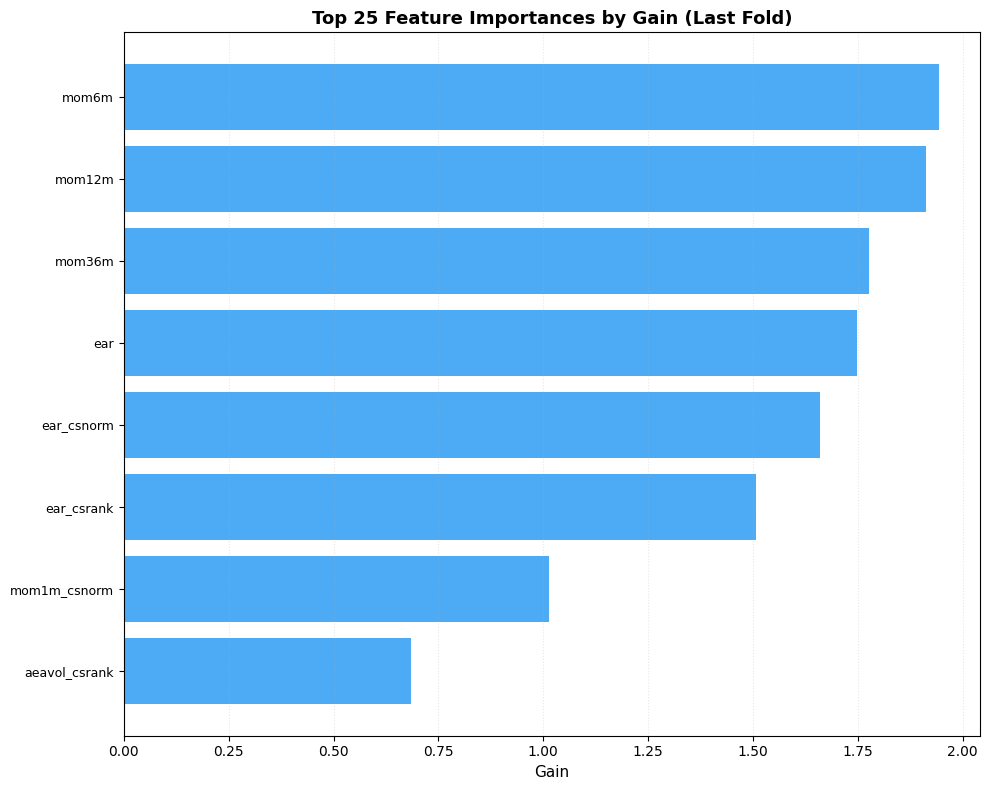

In [131]:
# Feature importance from last fold's model (top 25 by gain)
imp = last_model.get_score(importance_type="gain")
imp_sorted = sorted(imp.items(), key=lambda x: x[1], reverse=True)[:25]
feat_names, feat_gains = zip(*imp_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(feat_names)), feat_gains, color="#2196F3", alpha=0.8)
ax.set_yticks(range(len(feat_names)))
ax.set_yticklabels(feat_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Gain", fontsize=11)
ax.set_title("Top 25 Feature Importances by Gain (Last Fold)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x", linestyle=":")
plt.tight_layout()
plt.show()

c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


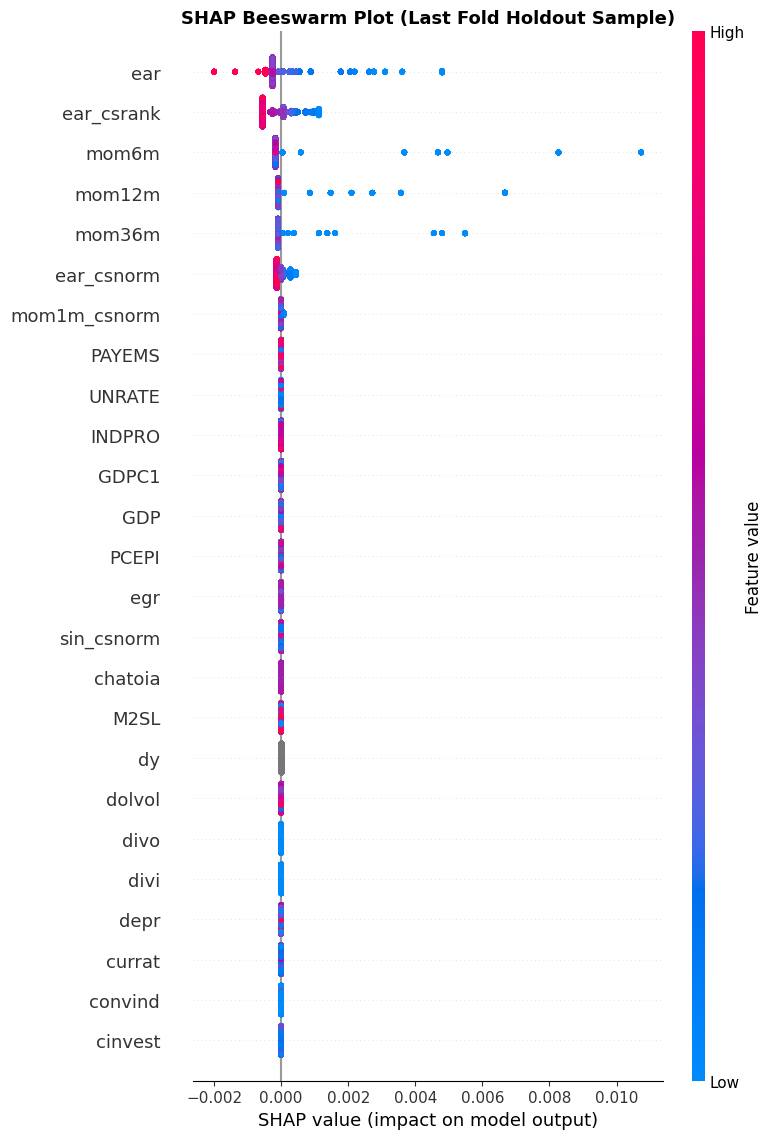

In [137]:
# %pip install shap
import shap

if last_model is None or last_holdout_frame is None or not last_feature_cols:
    raise ValueError("Run the holdout evaluation cell first to build last_model/last_holdout_frame.")

# Use a sample of the last fold's holdout data for SHAP
X_ho_shap = last_holdout_frame[last_feature_cols].copy()

n_sample = min(10000, len(X_ho_shap))
X_sample = X_ho_shap.sample(n=n_sample, random_state=42)

explainer = shap.TreeExplainer(last_model)
shap_values = explainer.shap_values(X_sample)

fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, X_sample, max_display=25, show=False)
plt.title("SHAP Beeswarm Plot (Last Fold Holdout Sample)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Per-Fold Holdout Backtest

Refit the best model on each fold's train+val data, generate predictions on the holdout period,
and run the backtesting engine with a long-only top 10% strategy.

In [141]:
# holdout_split_df, holdout_features = compute_cs_features_by_split(
#     model_df,
#     train_mask,
#     raw_gkx_cols,
#     macro_feature_cols,
#     date_col="month_end",
# )

# holdout_split_df.groupby(pd.qcut(holdout_split_df["ear"], 10))["ret_eom_t+1_zscore"].describe()

In [143]:
from src.backtest import (
    Backtester,
    LongOnlyTopPct,
    LongShortTopBottom,
    compute_metrics,
    print_metrics_comparison,
    create_backtest_report,
)

all_backtest_results = []

# Use tuned average best iteration for train+val refit (no holdout peeking)
default_rounds = int(np.nanmean(study.best_trial.user_attrs.get("per_fold_best_iter", [300])))
num_boost_round = max(default_rounds, 50)

for fold_info in folds:
    train_mask = fold_info["train_mask"]
    val_mask = fold_info["val_mask"]
    holdout_mask = fold_info["holdout_mask"]

    combined_mask = train_mask | val_mask

    fit_df, fit_features = compute_cs_features_by_split(
        model_df,
        combined_mask,
        raw_gkx_cols,
        macro_feature_cols,
        date_col="month_end",
    )
    holdout_split_df, holdout_features = compute_cs_features_by_split(
        model_df,
        holdout_mask,
        raw_gkx_cols,
        macro_feature_cols,
        date_col="month_end",
    )

    common_features = [c for c in fit_features if c in holdout_features]
    if not common_features:
        print(f"  Fold {fold_info['fold']}: skipped (no common features)")
        continue

    X_fit = fit_df[common_features].to_numpy(dtype=np.float32)
    y_fit = fit_df[target_col].to_numpy(dtype=np.float32)
    X_ho = holdout_split_df[common_features].to_numpy(dtype=np.float32)

    full_params = {
        "objective": "reg:pseudohubererror",
        "tree_method": "hist",
        "nthread": 3,
        **best_params,
    }

    dtrain = xgb.DMatrix(X_fit, label=y_fit, feature_names=common_features)
    dho = xgb.DMatrix(X_ho, feature_names=common_features)

    bst = xgb.train(
        full_params,
        dtrain,
        num_boost_round=num_boost_round,
        verbose_eval=False,
    )

    preds = bst.predict(dho)

    ho_data = holdout_split_df[["ticker", "month_end"]].copy()
    ho_data["pred"] = preds
    ho_data = ho_data.merge(
        px_m[["ticker", "month_end", "close"]],
        on=["ticker", "month_end"],
        how="left",
    )

    # Ensure benchmark prices are present even if SPY has no prediction row
    spy_rows = px_m.loc[
        (px_m["ticker"] == "SPY")
        & (px_m["month_end"] >= fold_info["holdout_start"])
        & (px_m["month_end"] <= fold_info["holdout_end"]),
        ["ticker", "month_end", "close"],
    ].copy()
    spy_rows["pred"] = np.nan

    ho_data = pd.concat([ho_data, spy_rows], ignore_index=True)
    ho_data = ho_data.drop_duplicates(["ticker", "month_end"], keep="first")
    ho_data = ho_data.dropna(subset=["close"])

    result = backtest_long_only(
        ho_data,
        top_pct=0.20,
        initial_capital=100000,
        bps=20,
        turnover_cap=None,
        date_col="month_end",
        ticker_col="ticker",
        pred_col="pred",
        price_col="close",
    )

    fold_label = (
        f"Fold {fold_info['fold']}: "
        f"{fold_info['holdout_start'].strftime('%Y-%m')} to "
        f"{fold_info['holdout_end'].strftime('%Y-%m')}"
    )

    all_backtest_results.append(
        {
            "fold": fold_info["fold"],
            "label": fold_label,
            "result": result,
            "metrics": result[4],
        }
    )
    
    print(f"{fold_label}", "\n", result[4])


C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\1603018104.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csnorm"] = (2.0 * cs_rank - 1.0).astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\1603018104.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csrank"] = cs_rank.astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\1603018104.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

Fold 0: 2007-02 to 2014-01 
               CAGR    Sharpe  Volatility  Max Drawdown
Strategy  0.165519  0.669077    0.290210     -0.534755
SPY       0.033772  0.281063    0.170668     -0.521953


C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\1603018104.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csnorm"] = (2.0 * cs_rank - 1.0).astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\1603018104.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csrank"] = cs_rank.astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\1603018104.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

Fold 1: 2012-02 to 2019-01 
               CAGR    Sharpe  Volatility  Max Drawdown
Strategy  0.136680  0.807953    0.179235     -0.228493
SPY       0.099914  0.920929    0.110377     -0.140341


C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\1603018104.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csnorm"] = (2.0 * cs_rank - 1.0).astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\1603018104.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f"{feat}_csrank"] = cs_rank.astype(np.float32)
C:\Users\amsac\AppData\Local\Temp\ipykernel_29440\1603018104.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

Fold 2: 2017-02 to 2024-01 
               CAGR    Sharpe  Volatility  Max Drawdown
Strategy  0.144785  0.618827    0.281528     -0.313519
SPY       0.110636  0.702662    0.170604     -0.247979


In [145]:
print(all_backtest_results[0]["result"][0]["hold_start"].min(), all_backtest_results[0]["result"][0]["hold_start"].max())
print(all_backtest_results[0]["metrics"])
print()
print(all_backtest_results[1]["result"][0]["hold_start"].min(), all_backtest_results[1]["result"][0]["hold_start"].max())
print(all_backtest_results[1]["metrics"])
print()
print(all_backtest_results[2]["result"][0]["hold_start"].min(), all_backtest_results[2]["result"][0]["hold_start"].max())
print(all_backtest_results[2]["metrics"])

2007-02-28 00:00:00 2013-12-31 00:00:00
              CAGR    Sharpe  Volatility  Max Drawdown
Strategy  0.165519  0.669077    0.290210     -0.534755
SPY       0.033772  0.281063    0.170668     -0.521953

2012-02-29 00:00:00 2018-12-31 00:00:00
              CAGR    Sharpe  Volatility  Max Drawdown
Strategy  0.136680  0.807953    0.179235     -0.228493
SPY       0.099914  0.920929    0.110377     -0.140341

2017-02-28 00:00:00 2023-12-31 00:00:00
              CAGR    Sharpe  Volatility  Max Drawdown
Strategy  0.144785  0.618827    0.281528     -0.313519
SPY       0.110636  0.702662    0.170604     -0.247979


## Check Beta exposure and returns in excess of SPY

In [ ]:
# import statsmodels.api as sm

# # Excess returns
# y = data["strategy"] - data["RF"]

# # Factors
# X = data[["Mkt-RF", "SMB", "HML", "MOM"]]
# X = sm.add_constant(X)

# model = sm.OLS(y, X).fit()

# print(model.summary())

## Save Best Params

In [ ]:
# Save best params to JSON (regression model, not XGBRanker)
save_params = {
    "objective": "reg:pseudohubererror",
    "tree_method": "hist",
    **best_params,
}

out_path = f"../data/processed/{run_tag}/best_xgb_reg_params.json"
with open(out_path, "w") as f:
    json.dump(save_params, f, indent=2)

print(f"Saved to {out_path}")
print(f"\nFull params for xgb.train():")
print(json.dumps(save_params, indent=2))
print(f"\nUsage:")
print(f"  import json, xgboost as xgb")
print(f'  params = json.load(open("{out_path}"))')
print(f"  model = xgb.train(params, dtrain, num_boost_round=1000, ...)")

## Simple backtesting code

In [139]:
def backtest_long_only(
    df,
    top_pct=0.10,
    initial_capital=100000,
    bps=20,
    turnover_cap=None,
    date_col="month_end",
    ticker_col="ticker",
    pred_col="pred",
    price_col="close",
):

    cost_rate = bps / 10000

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values([date_col, ticker_col])

    months = sorted(df[date_col].unique())
    by_month = {m: g for m, g in df.groupby(date_col)}

    portfolio = {}
    cash = initial_capital

    equity_curve = []
    rows = []

    for i in range(len(months) - 1):

        t0 = months[i]
        t1 = months[i + 1]

        g0 = by_month[t0]
        g1 = by_month[t1]

        p0 = dict(zip(g0[ticker_col], g0[price_col]))
        p1 = dict(zip(g1[ticker_col], g1[price_col]))

        # ---------- APPLY RETURNS ----------

        new_portfolio = {}

        for tk, value in portfolio.items():

            price0 = p0.get(tk)
            price1 = p1.get(tk)

            if price0 is None or price1 is None:
                continue

            new_portfolio[tk] = value * (price1 / price0)

        portfolio = new_portfolio

        portfolio_value = sum(portfolio.values())
        capital_before_rebalance = portfolio_value + cash

        # ---------- TARGET PORTFOLIO ----------

        g_valid = g0.dropna(subset=[pred_col, price_col])
        g_valid = g_valid[g_valid[price_col] > 0]

        n_target = max(1, int(len(g_valid) * top_pct))

        target = set(g_valid.nlargest(n_target, pred_col)[ticker_col])

        current = set(portfolio.keys())

        sells = list(current - target)
        buys = list(target - current)

        sell_notional = 0.0
        buy_notional = 0.0

        max_trade = np.inf
        if turnover_cap is not None:
            max_trade = turnover_cap * capital_before_rebalance

        # ---------- SELL ----------

        for tk in sells:

            value = portfolio.get(tk, 0)

            if sell_notional + buy_notional + value > max_trade:
                break

            sell_notional += value
            cash += value
            del portfolio[tk]

        # ---------- BUY ----------

        target_weight = 1 / max(len(target), 1)

        for tk in buys:

            desired = capital_before_rebalance * target_weight

            if sell_notional + buy_notional + desired > max_trade:
                break

            if cash < desired:
                break

            buy_notional += desired
            cash -= desired
            portfolio[tk] = desired

        # ---------- COSTS ----------

        traded_value = sell_notional + buy_notional
        txn_cost = traded_value * cost_rate
        cash -= txn_cost

        capital_end = cash + sum(portfolio.values())

        # ---------- TURNOVER METRICS ----------

        if capital_before_rebalance > 0:

            trading_turnover = traded_value / capital_before_rebalance
            portfolio_turnover = min(sell_notional, buy_notional) / capital_before_rebalance

        else:

            trading_turnover = 0
            portfolio_turnover = 0

        rows.append({
            "hold_start": t0,
            "hold_end": t1,
            "capital_start": capital_before_rebalance,
            "capital_end": capital_end,
            "trading_turnover": trading_turnover,
            "portfolio_turnover": portfolio_turnover,
            "txn_cost": txn_cost,
            "n_holdings": len(portfolio)
        })

        equity_curve.append((t1, capital_end))

        if capital_end <= 0:
            break

    periods = pd.DataFrame(rows)

    equity = pd.DataFrame(
        equity_curve,
        columns=[date_col, "equity"]
    ).set_index(date_col)

    # --------------------------------------------------
    # BUILD SPY BENCHMARK
    # --------------------------------------------------

    spy_df = df.query(f"{ticker_col} == 'SPY'").copy()

    spy_df = spy_df.sort_values(date_col)

    spy_df["ret"] = spy_df[price_col].pct_change()

    spy_df["spy_equity"] = (1 + spy_df["ret"]).cumprod() * initial_capital

    spy_equity = spy_df.set_index(date_col)[["spy_equity"]]

    # --------------------------------------------------
    # ALIGN SERIES
    # --------------------------------------------------

    comparison = equity.join(spy_equity, how="inner")

    strategy_ret = comparison["equity"].pct_change().dropna()
    spy_ret = comparison["spy_equity"].pct_change().dropna()

    # --------------------------------------------------
    # PERFORMANCE METRICS
    # --------------------------------------------------

    def perf_stats(returns, equity_curve):

        ann_factor = 12

        sharpe = returns.mean() / returns.std() * np.sqrt(ann_factor)

        cagr = (equity_curve.iloc[-1] / equity_curve.iloc[0]) ** (
            ann_factor / len(returns)
        ) - 1

        vol = returns.std() * np.sqrt(ann_factor)

        drawdown = equity_curve / equity_curve.cummax() - 1
        max_dd = drawdown.min()

        return {
            "CAGR": cagr,
            "Sharpe": sharpe,
            "Volatility": vol,
            "Max Drawdown": max_dd
        }

    strategy_stats = perf_stats(strategy_ret, comparison["equity"])
    spy_stats = perf_stats(spy_ret, comparison["spy_equity"])

    stats = pd.DataFrame([strategy_stats, spy_stats], index=["Strategy", "SPY"])

    return periods, equity, spy_equity, comparison, stats

## Determine if the strategy offers legitimate alpha

- Most likely to see
    ```
    Alpha ≈ 0–3% annual
    Market Beta ≈ 1.1–1.3
    Momentum Beta ≈ 0.3–0.7
    R² ≈ 0.6–0.8
    ```

- Interpretation
    ```
    High R² → mostly explained by factors
    High beta → market exposure
    High MOM → momentum strategy
    Low alpha → little true stock-specific alpha
    ```


In [ ]:
# --- Load ---
ff = pd.read_csv("../data/downloaded/F-F_Research_Data_Factors.CSV", skiprows=3)
mom = pd.read_csv("../data/downloaded/F-F_Momentum_Factor.CSV", skiprows=13)

# --- Clean FF ---
ff = ff.rename(columns={"Unnamed: 0": "date"})
ff = ff[ff["date"].str.isnumeric()]
ff["date"] = pd.to_datetime(ff["date"], format="%Y%m")
ff = ff.set_index("date").astype(float) / 100

# --- Clean Momentum ---
mom = mom.rename(columns={"Unnamed: 0": "date"})
mom = mom[mom["date"].str.isnumeric()]
mom["date"] = pd.to_datetime(mom["date"], format="%Y%m")
mom = mom.set_index("date").astype(float) / 100

# --- Combine ---
factors = ff.join(mom.rename(columns={"Mom": "MOM"})[["MOM"]])

factors = ff.join(mom.rename(columns={"Mom": "MOM"})[["MOM"]])

In [162]:
factors = ff.join(mom.rename(columns={"Mom": "MOM"})[["MOM"]])

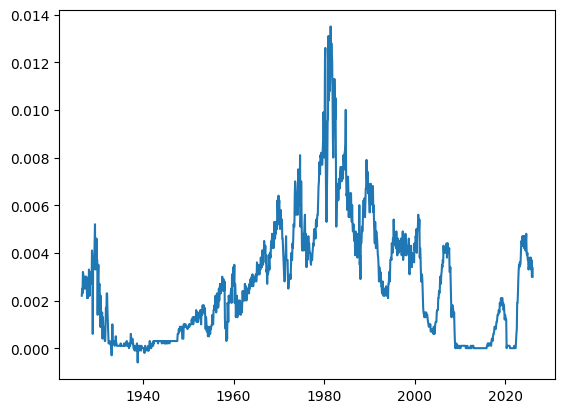

In [ ]:
plt.plot(factors.index, factors["RF"])

In [180]:
all_backtest_results[1]["result"]

(   hold_start   hold_end  capital_start    capital_end  trading_turnover  \
 0  2012-02-29 2012-03-31  100000.000000   99800.546448          0.997268   
 1  2012-03-31 2012-04-30   96293.724116   96050.676217          1.262013   
 2  2012-04-30 2012-05-31   87987.591790   87792.178443          1.110460   
 3  2012-05-31 2012-06-30   90946.502951   90702.969968          1.338880   
 4  2012-06-30 2012-07-31   92680.014991   92439.305620          1.298605   
 ..        ...        ...            ...            ...               ...   
 78 2018-08-31 2018-09-30  262813.918123  262151.857846          1.259561   
 79 2018-09-30 2018-10-31  234606.002777  234040.686482          1.204821   
 80 2018-10-31 2018-11-30  254048.197347  253422.192865          1.232058   
 81 2018-11-30 2018-12-31  212502.660657  211980.588477          1.228390   
 82 2018-12-31 2019-01-31  240041.096578  239511.644212          1.102837   
 
     portfolio_turnover    txn_cost  n_holdings  
 0             0.000000 

In [175]:
data = pd.concat([
    strategy_ret.rename("strategy"), # strategy, spy, returns, and date
    factors
], axis=1).dropna()

NameError: name 'strategy_ret' is not defined

In [ ]:
import statsmodels.api as sm

# Excess returns
y = data["strategy"] - data["RF"]

# Factors
X = data[["Mkt-RF", "SMB", "HML", "MOM"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

### SPY regression for comparison

In [ ]:
beta = model.params
tstats = model.tvalues

alpha_monthly = beta["const"]
alpha_annual = alpha_monthly * 12

print("\n--- Key Results ---")
print("Alpha (annual):", round(alpha_annual, 4))
print("Market Beta:", round(beta["Mkt-RF"], 2))
print("Momentum Beta:", round(beta["MOM"], 2))
print("R^2:", round(model.rsquared, 3))